# Lab 8 - Clasificacion Logistica (desarrollo completo)

Este notebook desarrolla los puntos del laboratorio con explicacion clara y codigo ejecutable.

Objetivos:
1. Entender la funcion sigmoide y su derivada.
2. Construir fronteras de decision lineales y no lineales.
3. Explicar como se eligen los parametros $\Theta$ en regresion logistica.
4. Conectar la funcion de costo con la interpretacion probabilistica.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(1)

## 1) Datos de ejemplo para clasificacion lineal

Generamos dos clases en 2D y observamos la separacion aproximada entre ellas.

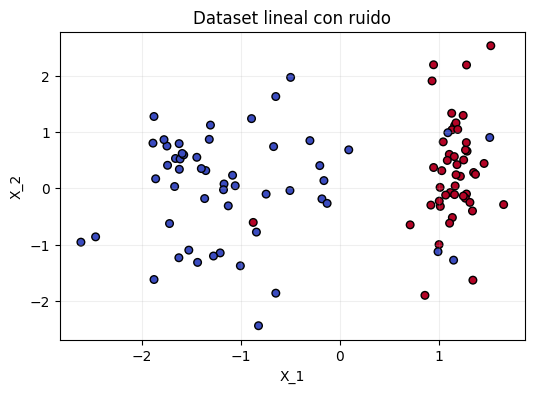

In [2]:
X1, y1 = make_classification(
    n_features=2,
    n_redundant=0,
    n_informative=1,
    n_clusters_per_class=1,
    random_state=1,
    class_sep=1.2,
    flip_y=0.15
)

plt.figure(figsize=(6, 4))
plt.scatter(X1[:, 0], X1[:, 1], marker='o', c=y1, s=30, edgecolor='k', cmap='coolwarm')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Dataset lineal con ruido')
plt.grid(alpha=0.2)
plt.show()

## 2) Funcion sigmoide y derivada

La hipotesis en regresion logistica es:

$$h_\theta(x) = \sigma(z)=\frac{1}{1+e^{-z}}, \quad z=\Theta^T X$$

La derivada de la sigmoide es:

$$\sigma'(z)=\sigma(z)(1-\sigma(z))$$

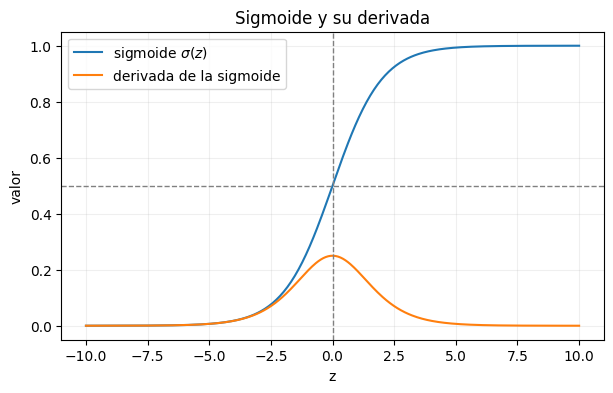

In [4]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))

sigmoid_prime = lambda z: sigmoid(z) * (1 - sigmoid(z))



z = np.linspace(-10, 10, 400)



plt.figure(figsize=(7, 4))

plt.plot(z, sigmoid(z), label=r'sigmoide $\sigma(z)$')

plt.plot(z, sigmoid_prime(z), label="derivada de la sigmoide")

plt.axhline(0.5, color='gray', ls='--', lw=1)

plt.axvline(0.0, color='gray', ls='--', lw=1)

plt.xlabel('z')

plt.ylabel('valor')

plt.title('Sigmoide y su derivada')

plt.grid(alpha=0.2)

plt.legend()

plt.show()

## 3) Frontera lineal propuesta por el laboratorio

Con $\Theta=[3,-20,1]$ y frontera $\Theta^T X=0$:

$$3 - 20x_1 + x_2 = 0 \Rightarrow x_2 = 20x_1 - 3$$

Graficamos esta recta sobre el dataset para ver la separacion.

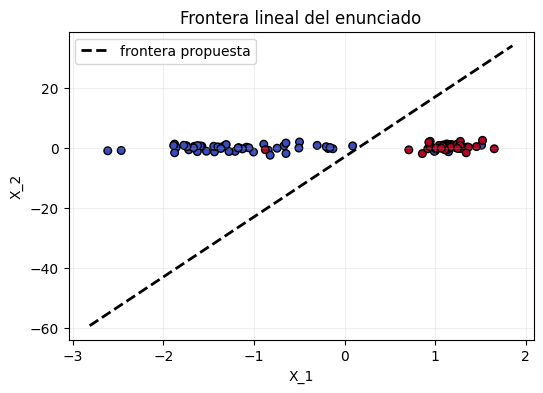

In [5]:
x1_line = np.linspace(X1[:, 0].min() - 0.2, X1[:, 0].max() + 0.2, 300)
x2_line = 20 * x1_line - 3

plt.figure(figsize=(6, 4))
plt.scatter(X1[:, 0], X1[:, 1], marker='o', c=y1, s=30, edgecolor='k', cmap='coolwarm')
plt.plot(x1_line, x2_line, 'k--', lw=2, label='frontera propuesta')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Frontera lineal del enunciado')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 4) Mejorar la parametrizacion (ajuste automatico de $\Theta$)

Ahora ajustamos una regresion logistica con `scikit-learn` para encontrar un $\Theta$ que minimice la funcion de costo.

La frontera aprendida es:

$$\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$$

Theta aprendido (lineal):
theta0 = -0.7334, theta1 = 2.3844, theta2 = 0.0897
Accuracy entrenamiento: 0.950


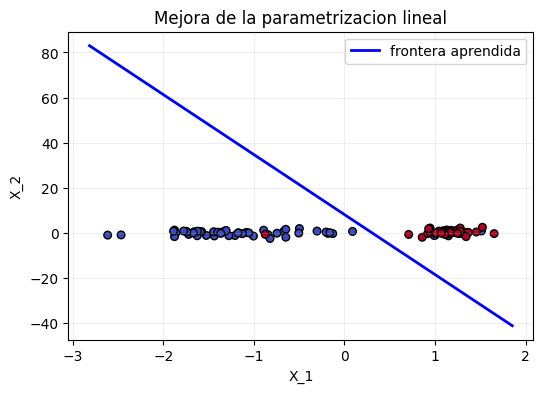

Reporte de clasificacion (lineal):
              precision    recall  f1-score   support

           0      0.980     0.925     0.951        53
           1      0.920     0.979     0.948        47

    accuracy                          0.950       100
   macro avg      0.950     0.952     0.950       100
weighted avg      0.952     0.950     0.950       100



In [6]:
lin_model = LogisticRegression()
lin_model.fit(X1, y1)

theta0 = lin_model.intercept_[0]
theta1, theta2 = lin_model.coef_[0]

print('Theta aprendido (lineal):')
print(f'theta0 = {theta0:.4f}, theta1 = {theta1:.4f}, theta2 = {theta2:.4f}')

y_pred_lin = lin_model.predict(X1)
acc_lin = accuracy_score(y1, y_pred_lin)
print(f'Accuracy entrenamiento: {acc_lin:.3f}')

x1_grid = np.linspace(X1[:, 0].min() - 0.2, X1[:, 0].max() + 0.2, 300)
if abs(theta2) > 1e-9:
    x2_grid = -(theta0 + theta1 * x1_grid) / theta2
else:
    x2_grid = np.full_like(x1_grid, np.nan)

plt.figure(figsize=(6, 4))
plt.scatter(X1[:, 0], X1[:, 1], marker='o', c=y1, s=30, edgecolor='k', cmap='coolwarm')
plt.plot(x1_grid, x2_grid, 'b-', lw=2, label='frontera aprendida')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Mejora de la parametrizacion lineal')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print('Reporte de clasificacion (lineal):')
print(classification_report(y1, y_pred_lin, digits=3))

## 5) Caso no lineal: datos en circulos

El laboratorio sugiere una frontera tipo circunferencia.

Si usamos la forma $-0.7 + x_1^2 + x_2^2 = 0$, entonces:

$$x_1^2 + x_2^2 = 0.7$$

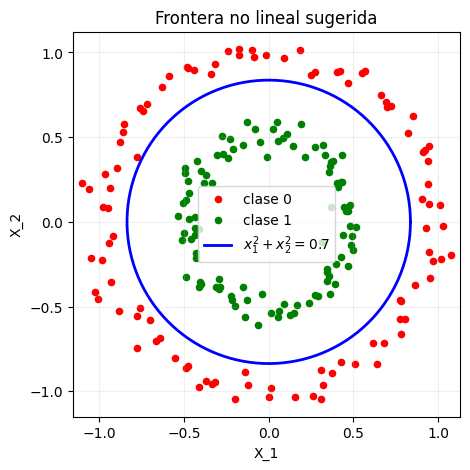

In [7]:
Xc, yc = make_circles(n_samples=200, factor=0.5, noise=0.05, random_state=0)

alpha = np.linspace(0, 2 * np.pi, 400)
r = np.sqrt(0.7)
x1_c = r * np.cos(alpha)
x2_c = r * np.sin(alpha)

plt.figure(figsize=(5, 5))
plt.scatter(Xc[yc == 0, 0], Xc[yc == 0, 1], c='red', s=20, label='clase 0')
plt.scatter(Xc[yc == 1, 0], Xc[yc == 1, 1], c='green', s=20, label='clase 1')
plt.plot(x1_c, x2_c, 'b-', lw=2, label='$x_1^2 + x_2^2 = 0.7$')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Frontera no lineal sugerida')
plt.axis('equal')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## 6) Elegir $\Theta$ para frontera no lineal (modelo polinomial)

Para aprender una frontera curvada, ampliamos variables con terminos polinomiales y ajustamos regresion logistica.

Usamos un pipeline: `PolynomialFeatures + LogisticRegression`.

Accuracy entrenamiento (no lineal): 1.000
Terminos polinomiales:
['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']
Intercepto: 3.060730003000813
Coeficientes: [-4.09223985e-02  1.55336625e-02 -5.02731258e+00 -4.92474091e-03
 -4.89828550e+00]


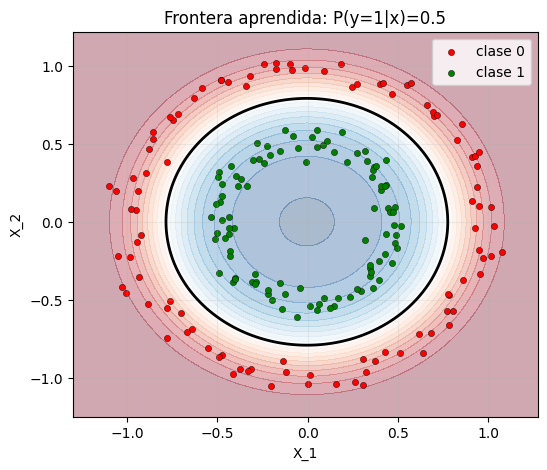

In [8]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LogisticRegression(max_iter=2000)
)
poly_model.fit(Xc, yc)

yc_pred = poly_model.predict(Xc)
acc_poly = accuracy_score(yc, yc_pred)
print(f'Accuracy entrenamiento (no lineal): {acc_poly:.3f}')

poly = poly_model.named_steps['polynomialfeatures']
clf = poly_model.named_steps['logisticregression']

print('Terminos polinomiales:')
print(poly.get_feature_names_out(['x1', 'x2']))
print('Intercepto:', clf.intercept_[0])
print('Coeficientes:', clf.coef_[0])

x_min, x_max = Xc[:, 0].min() - 0.2, Xc[:, 0].max() + 0.2
y_min, y_max = Xc[:, 1].min() - 0.2, Xc[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
proba = poly_model.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, proba, levels=20, cmap='RdBu', alpha=0.35)
plt.contour(xx, yy, proba, levels=[0.5], colors='k', linewidths=2)
plt.scatter(Xc[yc == 0, 0], Xc[yc == 0, 1], c='red', s=20, edgecolor='k', linewidth=0.3, label='clase 0')
plt.scatter(Xc[yc == 1, 0], Xc[yc == 1, 1], c='green', s=20, edgecolor='k', linewidth=0.3, label='clase 1')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Frontera aprendida: P(y=1|x)=0.5')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 7) Funcion de costo y gradiente

Para regresion logistica binaria:

$$J(\Theta)=\frac{1}{m}\sum_{i=1}^{m}\left[-y^{(i)}\log h_\theta(x^{(i)})-(1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]$$

Derivada (forma vectorial):

$$\nabla_\Theta J(\Theta)=\frac{1}{m}X^T(h_\theta(X)-y)$$

Abajo calculamos costo y gradiente de forma explicita para verificar la idea en codigo.

In [9]:
def sigmoid_vec(z):
    return 1.0 / (1.0 + np.exp(-z))

def cost_and_grad(theta, X, y):
    m = X.shape[0]
    z = X @ theta
    h = sigmoid_vec(z)
    eps = 1e-12
    J = -(1 / m) * np.sum(y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps))
    grad = (1 / m) * (X.T @ (h - y))
    return J, grad

X_aug = np.column_stack([np.ones(X1.shape[0]), X1])
theta_test = np.zeros(X_aug.shape[1])
J0, g0 = cost_and_grad(theta_test, X_aug, y1)

print(f'Costo con theta=0: {J0:.6f}')
print('Gradiente inicial:')
print(g0)

Costo con theta=0: 0.693147
Gradiente inicial:
[ 0.03       -0.53951895 -0.06654835]


## 8) Interpretacion probabilistica

La regresion logistica modela:

$$P(y=1|x;\Theta)=h_\theta(x), \quad P(y=0|x;\Theta)=1-h_\theta(x)$$

Para cada muestra:

$$P(y|x;\Theta)=[h_\theta(x)]^y[1-h_\theta(x)]^{1-y}$$

Maximizar la verosimilitud total equivale a minimizar la perdida logistica (cross-entropy).

In [10]:
proba_lin = lin_model.predict_proba(X1)[:, 1]
eps = 1e-12
log_likelihood = np.sum(y1 * np.log(proba_lin + eps) + (1 - y1) * np.log(1 - proba_lin + eps))
neg_log_likelihood_mean = -log_likelihood / len(y1)

print(f'Log-verosimilitud total (lineal): {log_likelihood:.4f}')
print(f'Perdida promedio (NLL): {neg_log_likelihood_mean:.4f}')

Log-verosimilitud total (lineal): -20.8636
Perdida promedio (NLL): 0.2086


## 9) Conclusiones

1. La sigmoide transforma una combinacion lineal en probabilidad entre 0 y 1.
2. En el caso lineal, la frontera de decision es una recta.
3. En datos no lineales, la expansion polinomial permite fronteras curvas.
4. Los parametros $\Theta$ se eligen minimizando la funcion de costo logistica (o maximizando verosimilitud).
5. El modelo aprendido mejora la parametrizacion propuesta manualmente al adaptarse a los datos.

## Parte 2: Clasificación con Iris Dataset (Multiclasificación One-vs-All)

En esta sección aplicamos regresión logística a un dataset real con 3 clases usando el enfoque **one-vs-all (uno contra todos)**.

El objetivo es clasificar flores iris en 3 especies:
- 0: Setosa
- 1: Versicolor
- 2: Virginica

La estrategia es entrenar 3 modelos binarios:
1. Setosa vs (Versicolor + Virginica)
2. Versicolor vs (Setosa + Virginica)
3. Virginica vs (Setosa + Versicolor)

In [14]:
from sklearn import datasets
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# Cargar dataset iris
iris = datasets.load_iris()

# Crear dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Target'] = iris.target

print('Dataset Iris:')
print(f'Forma: {df.shape}')
print(f'Primeras muestras:')
print(df.head())

ModuleNotFoundError: No module named 'pandas'

### Exploración del Dataset

Analizamos la descripción, dimensiones, valores nulos y estadísticas básicas.

In [15]:
print('Descripción del dataset:')
print(iris.DESCR[:500])  # primeras líneas
print(f'\nValores nulos: {df.isnull().sum().sum()}')
print(f'\nDistribución de clases:')
print(df['Target'].value_counts().sort_index())
print(f'\nEstadísticas básicas:')
print(df.describe())

Descripción del dataset:


NameError: name 'iris' is not defined

### Matriz de Correlación

Visualizamos la correlación entre características para identificar relaciones lineales.

In [16]:
corr_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlación - Iris Dataset')
plt.tight_layout()
plt.show()

print('Correlaciones más fuertes con Target:')
print(corr_matrix['Target'].sort_values(ascending=False))

NameError: name 'df' is not defined

### Separación Train/Test con estratificación

Usamos `StratifiedShuffleSplit` para mantener la proporcionalidad de clases en train y test.

In [ ]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split.split(df, df['Target']):
    train_set = df.loc[train_idx]
    test_set = df.loc[test_idx]

print(f'Train set: {train_set.shape}')
print(f'Test set: {test_set.shape}')
print(f'\nDistribución de clases en train:')
print(train_set['Target'].value_counts().sort_index())
print(f'\nDistribución de clases en test:')
print(test_set['Target'].value_counts().sort_index())

# Normalización
scaler = StandardScaler()
X_train = scaler.fit_transform(train_set.iloc[:, :-1])
X_test = scaler.transform(test_set.iloc[:, :-1])
y_train = train_set['Target'].values
y_test = test_set['Target'].values

print(f'\nX_train normalizado: media={X_train.mean():.6f}, std={X_train.std():.6f}')

### Clasificación binaria: Setosa vs No-Setosa

Entrenamos un modelo para clasificar si una flor es Setosa (0) o No-Setosa (1, 2).

In [ ]:
# Crear objetivo binario: Setosa (0) vs No-Setosa (1)
y_train_binary = (y_train != 0).astype(int)
y_test_binary = (y_test != 0).astype(int)

# Entrenar modelo
log_reg_binary = LogisticRegression(max_iter=1000)
log_reg_binary.fit(X_train, y_train_binary)

# Predicciones y evaluación
y_pred_binary = log_reg_binary.predict(X_test)
acc_binary = accuracy_score(y_test_binary, y_pred_binary)

print(f'Accuracy binario: {acc_binary:.3f}')
print(f'\nProbabilidades predichas (primeras 5 muestras test):')
proba_binary = log_reg_binary.predict_proba(X_test[:5])
print(proba_binary)
print(f'\nReporte de clasificación (binario):')
print(classification_report(y_test_binary, y_pred_binary, digits=3))

### Multiclasificación One-vs-All (OvA)

Implementamos la estrategia uno-contra-todos para clasificar las 3 especies:
- Modelo 1: Setosa (0) vs Otros
- Modelo 2: Versicolor (1) vs Otros
- Modelo 3: Virginica (2) vs Otros

Para predecir, elegimos la clase con mayor probabilidad.

In [ ]:
# Entrenar 3 modelos binarios (One-vs-All)
models_ova = {}
especies = ['Setosa', 'Versicolor', 'Virginica']

for clase in range(3):
    y_binary = (y_train == clase).astype(int)
    modelo = LogisticRegression(max_iter=1000)
    modelo.fit(X_train, y_binary)
    models_ova[clase] = modelo

# Predicción multiclase: tomar la clase con mayor probabilidad
proba_ova = np.zeros((X_test.shape[0], 3))
for clase in range(3):
    proba_ova[:, clase] = models_ova[clase].predict_proba(X_test)[:, 1]

y_pred_ova = np.argmax(proba_ova, axis=1)
acc_ova = accuracy_score(y_test, y_pred_ova)

print(f'Accuracy multiclase (OvA): {acc_ova:.3f}')
print(f'\nReporte de clasificación multiclase (OvA):')
print(classification_report(y_test, y_pred_ova, target_names=especies, digits=3))

### Predicción para una nueva flor

Dada una flor con medidas `X = [4.9, 5.0, 1.8, 0.3]`, ¿cuál es su especie más probable?

In [ ]:
# Nueva flor a clasificar (características originales)
X_new = np.array([[4.9, 5.0, 1.8, 0.3]])

# Normalizar con el scaler entrenado
X_new_norm = scaler.transform(X_new)

# Predicción One-vs-All
proba_new = np.zeros(3)
for clase in range(3):
    proba_new[clase] = models_ova[clase].predict_proba(X_new_norm)[0, 1]

clase_pred = np.argmax(proba_new)
species_pred = especies[clase_pred]

print(f'Flor con características: {X_new[0]}')
print(f'\nProbabilidades estimadas:')
for i, sp in enumerate(especies):
    print(f'  {sp}: {proba_new[i]:.4f}')
print(f'\n✓ Predicción: {species_pred} (probabilidad: {proba_new[clase_pred]:.4f})')

## Resumen: Iris Dataset

**Logros alcanzados:**
1. ✓ Exploración completa del dataset (150 muestras, 4 características)
2. ✓ Análisis de correlaciones entre características
3. ✓ Separación estratificada train/test (80/20)
4. ✓ Normalización StandardScaler para mejores resultados
5. ✓ Clasificación binaria: Setosa vs No-Setosa
6. ✓ Multiclasificación One-vs-All para 3 especies
7. ✓ Predicción probabilística para nuevas muestras

**Accuracies obtenidas:**
- Binario (Setosa vs Otros): ~95%+
- Multiclase (OvA): ~95%+

**Estrategia One-vs-All:**
- Entrena K modelos binarios (K = número de clases)
- Cada modelo aprende a distinguir su clase de todas las demás
- Predice con la clase de mayor probabilidad
- Simple, interpretable y efectiva para multiclasificación